# 선문대학교 컴퓨터공학부
# 2022243101 최완우

# **9장 합성곱 신경망**
---
* 출판사 : 생능 출판사( http://www.booksr.co.kr/ )
* 으뜸 머신러닝 저자 : 강영민, 박동규, 김성수
*  소스코드 저장소 : https://github.com/dknife/ML2nd
*  저작권 : 본 노트북 코드는 자유롭게 배포가능하지만 위의 출판사, 저서, 저자표기와 함께 배포해 주십시오.
---

### **LAB 9-2 : 합성곱 신경망으로 패션 MNIST 분류를 개선하기**

In [1]:
# tenserflow와 tf.keras를 임포트한다
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# 패션 MNIST 데이터를 학습용 데이터, 테스트 데이터로 구분
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 34s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 7s 2us/step


In [ ]:
print(train_images.shape) # 학습 이미지의 형태와 레이블을 출력한다
print(train_labels)
print(test_images.shape)

(60000, 28, 28)
[9 0 0 ... 3 0 5]
(10000, 28, 28)


In [3]:
train_images = train_images[:, :, :, np.newaxis]
test_images = test_images[:, :, :, np.newaxis]

In [4]:
model = keras.models.Sequential( [
    keras.layers.Conv2D(input_shape = (28, 28, 1),
                        kernel_size = (3, 3), padding = 'same',
                        filters = 32),
    keras.layers.MaxPooling2D((2, 2), strides = 2),
    keras.layers.Conv2D(kernel_size = (3, 3), padding = 'same',
                        filters = 32),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation = 'relu'),
    keras.layers.Dense(32, activation = 'relu'),
    keras.layers.Dense(10, activation = 'softmax'),
])

C:\Users\최완우\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 816,970 (3.12 MB)

 Trainable params: 816,970 (3.12 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])
history = model.fit(train_images, train_labels,
                    epochs = 5, validation_split = 0.25)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7900 - loss: 0.9065 - val_accuracy: 0.8096 - val_loss: 0.5684
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8617 - loss: 0.3970 - val_accuracy: 0.8735 - val_loss: 0.3659
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8814 - loss: 0.3289 - val_accuracy: 0.8810 - val_loss: 0.3501
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8907 - loss: 0.3023 - val_accuracy: 0.8715 - val_loss: 0.3804
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8973 - loss: 0.2862 - val_accuracy: 0.8827 - val_loss: 0.3445


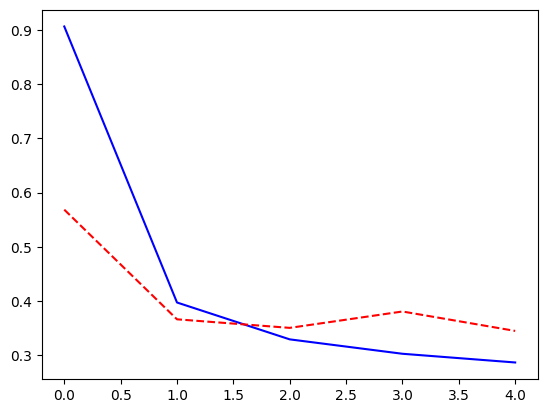

In [7]:
plt.plot(history.history['loss'], 'b-')
plt.plot(history.history['val_loss'], 'r--')

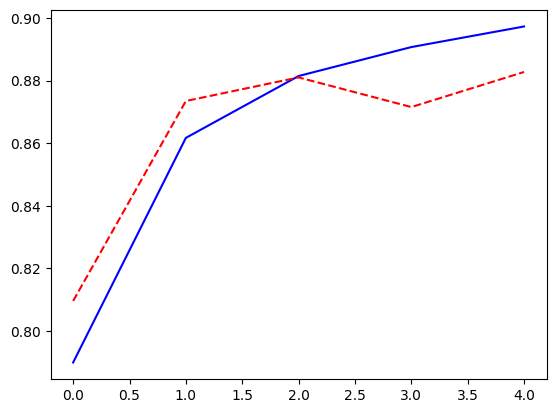

In [8]:
plt.plot(history.history['accuracy'], 'b-')
plt.plot(history.history['val_accuracy'], 'r--')

In [9]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose = 2)
print('테스트 정확도 : ', test_acc)

313/313 - 1s - 5ms/step - accuracy: 0.8796 - loss: 0.3613
테스트 정확도 :  0.8795999884605408


In [10]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [11]:
randldx = np.random.randint(0, 1000)

images = test_images[randldx:randldx + 25]
predictions = np.argmax(model.predict(images), axis = 1)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
[1 8 4 2 9 2 8 3 2 4 4 7 1 4 9 3 5 8 5 4 7 2 8 5 9]


In [12]:
def plot_images(images, labels, images_per_row = 5) :
    n_images = len(images)
    n_rows = (n_images - 1) // images_per_row + 1
    fig, ax = plt.subplots(n_rows, images_per_row,
                           figsize = (images_per_row * 2, n_rows * 2))
    for i in range(n_rows) :
        for j in range(images_per_row) :
            if i * images_per_row + j >= n_images : break
            img_idx = i * images_per_row + j
            a_image = images[img_idx].reshape(28, 28)
            if n_rows > 1 : axis = ax[i, j]
            else : axis = ax[j]
            axis.get_xaxis().set_visible(False)
            axis.get_yaxis().set_visible(False)
            label = class_names[labels[img_idx]]
            axis.set_title(label)
            axis.imshow(a_image, cmap = 'gray', interpolation = 'nearest')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


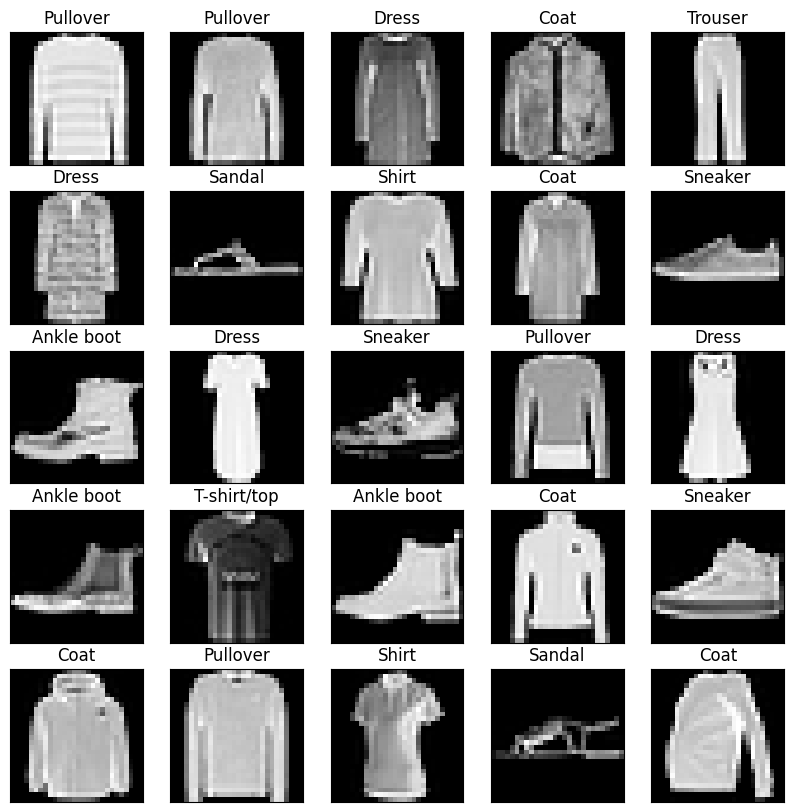

In [13]:
randldx = np.random.randint(0, 1000)

images = test_images[randldx:randldx + 25]
predictions = np.argmax(model.predict(images), axis = 1)
plot_images(images, predictions, images_per_row = 5)